# BMMC RNA-ATAC aligned UMAP visualization

This notebook visualizes the **shared aligned latent representation** learned by scMRDR for **BMMC RNA-ATAC**.

It reads:

```python
adata.obsm["latent_shared"]
```

from each `training_adata_post.h5ad`.

Unlike PBMC, **BMMC already contains cell-type annotations in `adata.obs`**, so this notebook does **not** read any external annotation CSV. It uses the existing BMMC cell-type column directly.

The modality-colored and cell-type-colored panels always use the **same UMAP coordinates**.


## 1. Imports

`ipywidgets` is optional and is only required for the interactive explorer.

```bash
pip install ipywidgets
```


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets is not installed. Interactive controls will be skipped.")

sc.settings.verbosity = 2

print("scanpy:", sc.__version__)
print("ipywidgets available:", HAS_WIDGETS)


scanpy: 1.10.3
ipywidgets available: True


## 2. Settings

Normally, only `PROJECT_ROOT` needs to be changed.

The notebook first prefers `celltype` (the coarse BMMC annotation produced during preprocessing), then falls back to other common annotation column names such as `cell_type`.


In [2]:
PROJECT_ROOT = Path("/data5/zhangye/scMRDR")

EXPERIMENT_NAME = 'BMMC RNA-ATAC'
OUT_ROOT = PROJECT_ROOT / 'output/BMMC/scMRDR_results_atac_to_rna'

POST_H5AD_NAME = "training_adata_post.h5ad"
LATENT_KEY = "latent_shared"
MODALITY_KEY = "modality"

EXPECTED_MODALITIES = ['rna', 'atac']

# BMMC annotations are already stored in adata.obs.
PREFERRED_CELLTYPE_KEY = 'celltype'
CELLTYPE_CANDIDATES = [
    "celltype",
    "cell_type",
    "cell_types",
    "CellType",
    "cell_type_l1",
    "cell_type_l2",
    "annotation",
    "label",
    "labels",
]

N_NEIGHBORS = 30
MIN_DIST = 0.35
RANDOM_STATE = 1234
MAX_CELLS = None

POINT_SIZE = 5.0
POINT_ALPHA = 0.75
DPI = 300

print("Experiment:", EXPERIMENT_NAME)
print("Output root:", OUT_ROOT)


Experiment: BMMC RNA-ATAC
Output root: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna


## 3. Data-loading utilities

Cell types are read **directly from `training_adata_post.h5ad`**. No external annotation file is used.


In [7]:
def discover_ratios():
    """Find ratio folders containing training_adata_post.h5ad."""
    if not OUT_ROOT.exists():
        return []

    return [
        d.name
        for d in sorted(OUT_ROOT.glob("single_*"))
        if d.is_dir() and (d / POST_H5AD_NAME).exists()
    ]


def available_celltype_keys(obs):
    """Return likely BMMC cell-type annotation columns."""
    keys = []
    for key in CELLTYPE_CANDIDATES:
        if key in obs.columns and key not in keys:
            keys.append(key)
    return keys


def resolve_celltype_key(obs, requested_key=None):
    """Choose the BMMC cell-type column stored in adata.obs."""
    if requested_key is not None:
        if requested_key not in obs.columns:
            raise KeyError(
                f"Requested cell-type key {requested_key!r} is unavailable. "
                f"Available obs columns: {list(obs.columns)}"
            )
        return requested_key

    if PREFERRED_CELLTYPE_KEY in obs.columns:
        return PREFERRED_CELLTYPE_KEY

    keys = available_celltype_keys(obs)
    return keys[0] if keys else None


def pretty_modality(value):
    value = str(value).strip().lower()
    mapping = {
        "rna": "RNA",
        "atac": "ATAC",
        "protein": "Protein",
        "adt": "Protein",
    }
    return mapping.get(value, str(value))


def inspect_training_output(ratio_label):
    """Inspect one post-training AnnData before plotting."""
    path = OUT_ROOT / ratio_label / POST_H5AD_NAME
    if not path.exists():
        raise FileNotFoundError(path)

    source = sc.read_h5ad(path)

    print("File:", path)
    print("Shape:", source.shape)
    print("obsm keys:", list(source.obsm.keys()))
    print("obs columns:", list(source.obs.columns))

    if LATENT_KEY in source.obsm:
        print(f"{LATENT_KEY} shape:", source.obsm[LATENT_KEY].shape)

    if MODALITY_KEY in source.obs:
        print(
            "Modalities:",
            source.obs[MODALITY_KEY].astype(str).value_counts().to_dict(),
        )

    keys = available_celltype_keys(source.obs)
    print("Detected cell-type columns:", keys)

    for key in keys:
        print(f"\n{key}:")
        print(source.obs[key].astype(str).value_counts(dropna=False).head(30))


def load_aligned_embedding(
    ratio_label,
    max_cells=MAX_CELLS,
    random_state=RANDOM_STATE,
    celltype_key=None,
):
    """Load latent_shared and the BMMC annotations already stored in adata.obs."""
    path = OUT_ROOT / ratio_label / POST_H5AD_NAME
    if not path.exists():
        raise FileNotFoundError(
            f"Missing training output: {path}\n"
            "Run the corresponding training script first."
        )

    source = sc.read_h5ad(path)

    if LATENT_KEY not in source.obsm:
        raise KeyError(
            f"{LATENT_KEY!r} not found. Available obsm keys: {list(source.obsm.keys())}"
        )

    if MODALITY_KEY not in source.obs.columns:
        raise KeyError(
            f"{MODALITY_KEY!r} not found. Available obs columns: {list(source.obs.columns)}"
        )

    latent = np.asarray(source.obsm[LATENT_KEY], dtype=np.float32)
    obs = source.obs.copy()

    resolved_celltype_key = resolve_celltype_key(
        obs,
        requested_key=celltype_key,
    )

    if resolved_celltype_key is None:
        warnings.warn(
            "No BMMC cell-type column was detected in training_adata_post.h5ad. "
            "Run inspect_training_output() and set PREFERRED_CELLTYPE_KEY if needed."
        )

    if max_cells is not None and len(obs) > max_cells:
        rng = np.random.default_rng(random_state)
        keep = np.sort(rng.choice(len(obs), size=max_cells, replace=False))
        latent = latent[keep]
        obs = obs.iloc[keep].copy()

    plot_adata = ad.AnnData(X=latent, obs=obs)

    plot_adata.obs["_modality_plot"] = (
        plot_adata.obs[MODALITY_KEY].astype(str).map(pretty_modality)
    )

    if resolved_celltype_key is not None:
        celltype_series = plot_adata.obs[resolved_celltype_key]

        plot_adata.obs["_celltype_plot"] = (
            celltype_series.astype("object")
            .where(celltype_series.notna(), "Unknown")
            .astype(str)
        )

    plot_adata.uns["ratio_label"] = ratio_label
    plot_adata.uns["celltype_key"] = resolved_celltype_key
    plot_adata.uns["source_file"] = str(path)

    return plot_adata, resolved_celltype_key


def compute_umap(
    plot_adata,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    random_state=RANDOM_STATE,
):
    """Compute UMAP directly from the scMRDR shared latent representation."""
    result = plot_adata.copy()

    sc.pp.neighbors(
        result,
        n_neighbors=n_neighbors,
        use_rep="X",
        random_state=random_state,
    )
    sc.tl.umap(
        result,
        min_dist=min_dist,
        random_state=random_state,
    )

    return result


## 4. Plotting functions

In [8]:
MODALITY_PALETTE = {
    "RNA": "#4C78A8",
    "ATAC": "#E78AC3",
    "Protein": "#59A14F",
}


def make_celltype_palette(labels):
    labels = sorted(pd.unique(pd.Series(labels).astype(str)))
    base = list(sc.pl.palettes.default_102)
    palette = {label: base[i % len(base)] for i, label in enumerate(labels)}
    if "Unknown" in palette:
        palette["Unknown"] = "#BDBDBD"
    return palette


def _clean_axis(ax, title):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def _scatter_categories(ax, coords, labels, palette, point_size, alpha):
    categories = sorted(pd.unique(labels))
    if "Unknown" in categories:
        categories = ["Unknown"] + [x for x in categories if x != "Unknown"]

    for label in categories:
        mask = labels == label
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=point_size,
            alpha=min(alpha, 0.35) if label == "Unknown" else alpha,
            linewidths=0,
            rasterized=True,
            label=label,
            c=[palette.get(label, "#BDBDBD")],
        )
    return categories


def plot_alignment_pair(
    adata_umap,
    save_dir=None,
    file_prefix=None,
    point_size=POINT_SIZE,
    alpha=POINT_ALPHA,
    dpi=DPI,
):
    """Plot modality and cell type using the same UMAP coordinates."""
    coords = np.asarray(adata_umap.obsm["X_umap"])
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3), dpi=dpi)

    modality = adata_umap.obs["_modality_plot"].astype(str).to_numpy()
    _scatter_categories(
        axes[0], coords, modality, MODALITY_PALETTE, point_size, alpha
    )
    _clean_axis(axes[0], "Colored by modality")
    axes[0].legend(
        title="Modality",
        frameon=False,
        markerscale=2,
        loc="best",
    )

    celltype_key = adata_umap.uns.get("celltype_key")
    if celltype_key is not None and "_celltype_plot" in adata_umap.obs:
        celltype = adata_umap.obs["_celltype_plot"].astype(str).to_numpy()
        palette = make_celltype_palette(celltype)
        categories = _scatter_categories(
            axes[1], coords, celltype, palette, point_size, alpha
        )
        _clean_axis(axes[1], f"Colored by cell type ({celltype_key})")

        axes[1].legend(
            title="Cell type",
            frameon=False,
            fontsize=8,
            title_fontsize=9,
            markerscale=1.8,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            ncol=1 if len(categories) <= 14 else 2,
        )
    else:
        _clean_axis(axes[1], "Cell type annotation unavailable")
        axes[1].text(
            0.5,
            0.5,
            "No usable cell-type annotation was found.",
            ha="center",
            va="center",
            transform=axes[1].transAxes,
        )

    ratio = adata_umap.uns.get("ratio_label", "")
    fig.suptitle(f"{EXPERIMENT_NAME} — {ratio}", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        if file_prefix is None:
            file_prefix = f"aligned_umap_{ratio}"

        png_path = save_dir / f"{file_prefix}.png"
        pdf_path = save_dir / f"{file_prefix}.pdf"
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print("Saved:", png_path)
        print("Saved:", pdf_path)

    plt.show()
    return fig


def save_umap_coordinates(adata_umap, path):
    """Save UMAP coordinates and plotting labels."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(
        {
            "UMAP1": adata_umap.obsm["X_umap"][:, 0],
            "UMAP2": adata_umap.obsm["X_umap"][:, 1],
            "modality": adata_umap.obs["_modality_plot"].astype(str).to_numpy(),
        },
        index=adata_umap.obs_names,
    )

    if "_celltype_plot" in adata_umap.obs:
        df["cell_type"] = adata_umap.obs["_celltype_plot"].astype(str).to_numpy()

    df.to_csv(path)
    print("Saved:", path)


## 5. Inspect one completed ratio

Run this once first to confirm that the BMMC cell-type column is present in `adata.obs`.


In [9]:
available_ratios = discover_ratios()
print("Available ratios:", available_ratios)

if available_ratios:
    inspect_training_output(available_ratios[0])
else:
    print("No completed ratio folders were found under:", OUT_ROOT)


Available ratios: ['single_000', 'single_020', 'single_040', 'single_060', 'single_080', 'single_100']
File: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/single_000/training_adata_post.h5ad
Shape: (92829, 12093)
obsm keys: ['latent_shared', 'latent_specific']
obs columns: ['GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'n_genes_by_counts', 'total_counts', 'n_genes', 'modality', 'dataset_block', 'is_val_query']
latent_shared shape: (92829, 20)
Modalities: {'atac': 51572, 'rna': 41257}
Detected cell-type columns: ['cell_type']

cell_type:
cell_type
CD8+ T          

/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 6. Quick UMAP

By default the notebook uses `celltype` when available. Set `CELLTYPE_KEY` manually if you prefer another BMMC annotation column.


Available ratios: ['single_000', 'single_020', 'single_040', 'single_060', 'single_080', 'single_100']

Plotting ratio: single_000
Using cell-type key: cell_type
computing neighbors


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


    finished (0:00:21)
computing UMAP
    finished (0:02:26)
Saved: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/aligned_umap_single_000.png
Saved: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/aligned_umap_single_000.pdf


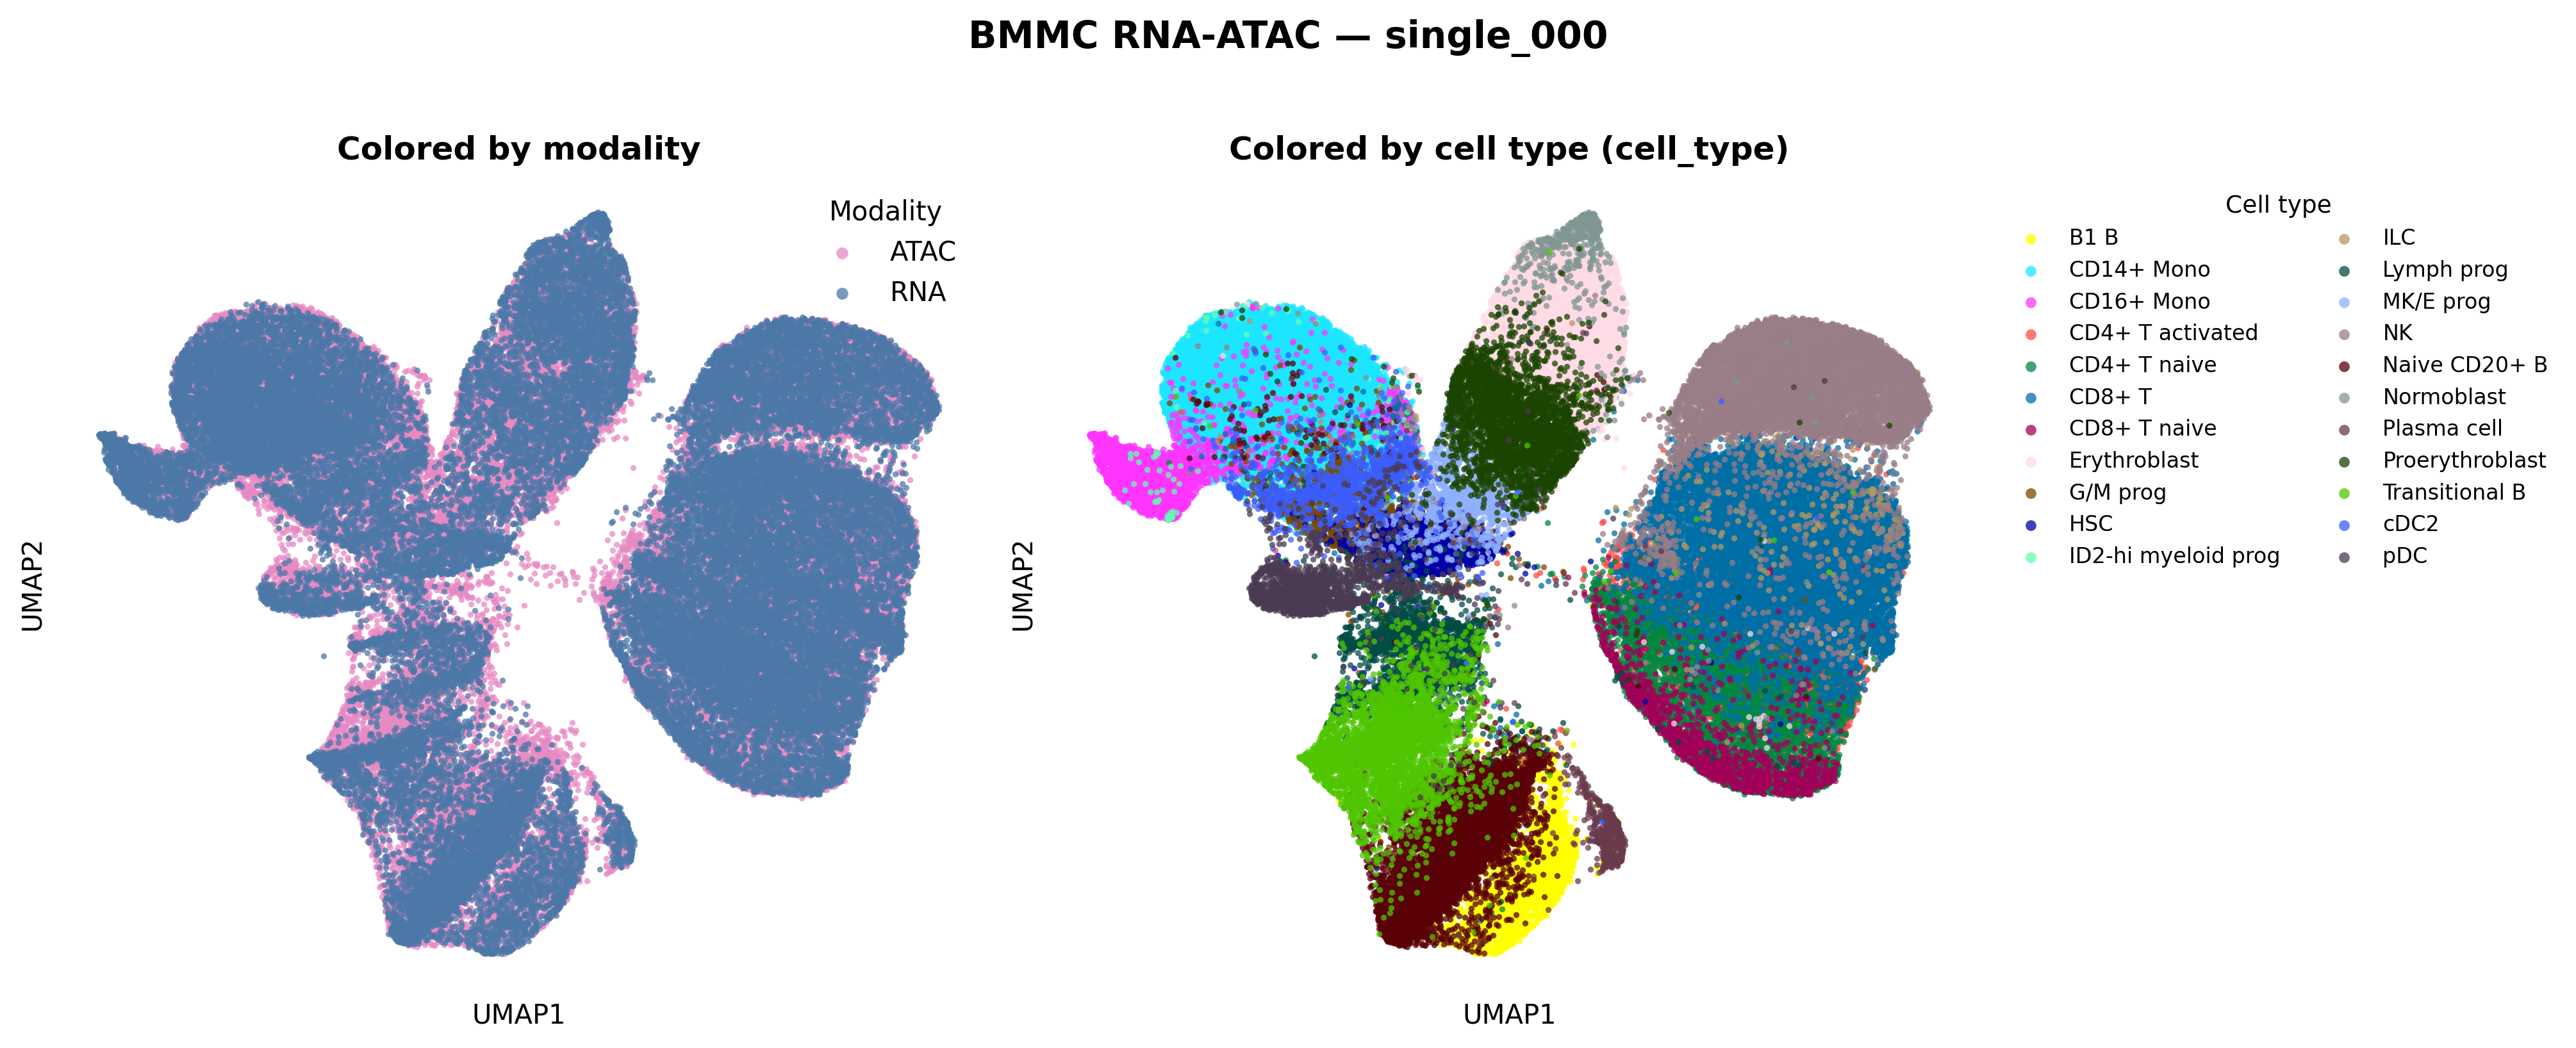

Saved: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/aligned_umap_single_000_coordinates.csv

Plotting ratio: single_020
Using cell-type key: cell_type
computing neighbors


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


    finished (0:00:16)
computing UMAP
    finished (0:02:07)
Saved: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/aligned_umap_single_020.png
Saved: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/aligned_umap_single_020.pdf


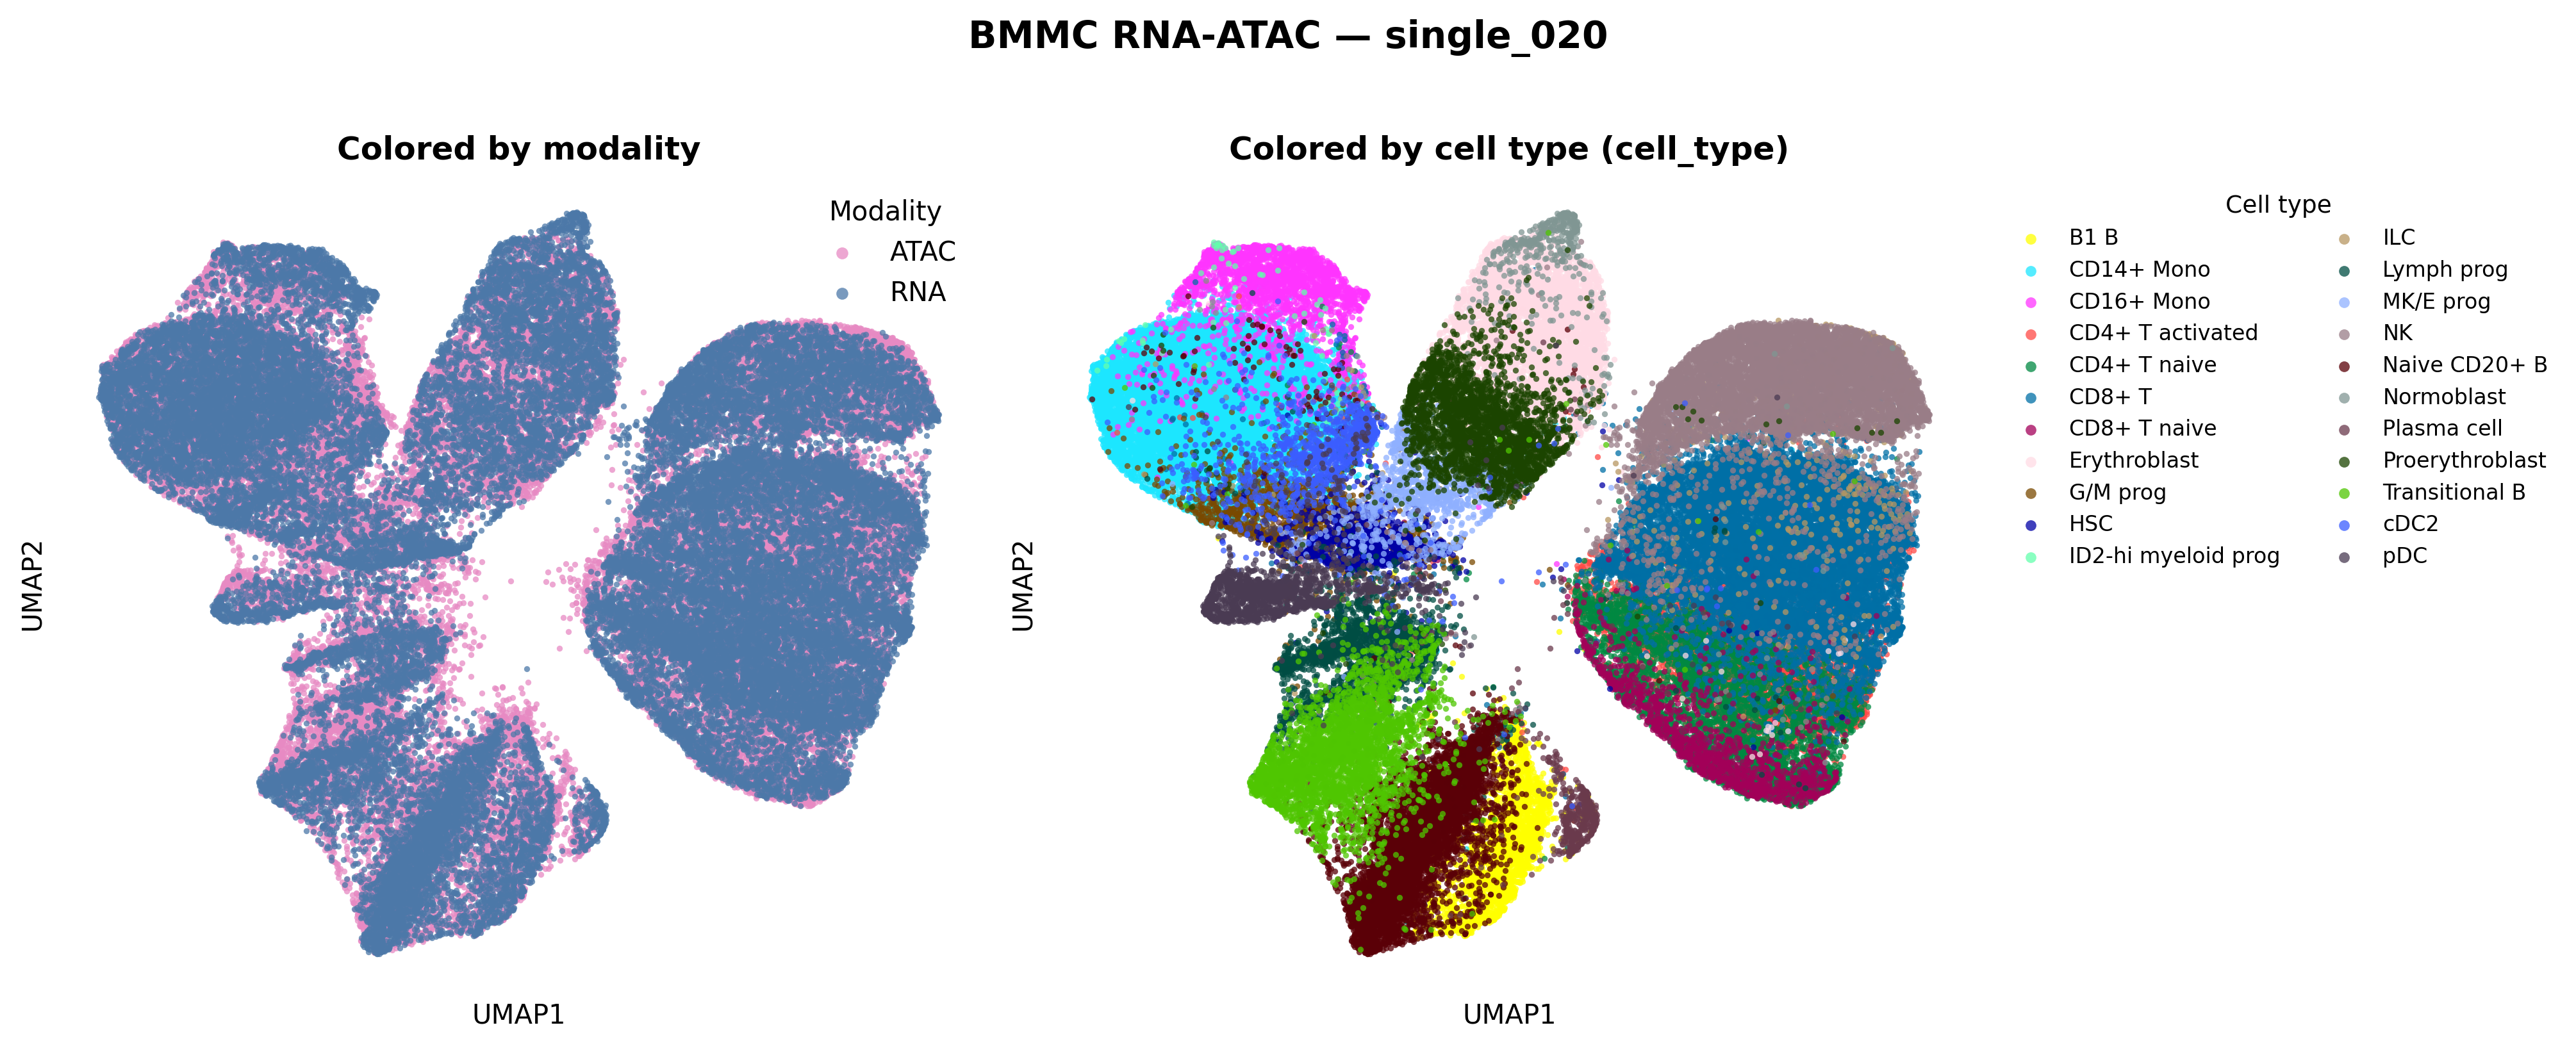

Saved: /data5/zhangye/scMRDR/output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/aligned_umap_single_020_coordinates.csv

Plotting ratio: single_040


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Using cell-type key: cell_type
computing neighbors


/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


    finished (0:00:15)
computing UMAP


In [ ]:
CELLTYPE_KEY = None  # e.g. "celltype" or "cell_type"

available_ratios = discover_ratios()
print("Available ratios:", available_ratios)

if available_ratios:

    figure_dir = OUT_ROOT / "figures" / "alignment_umap"
    figure_dir.mkdir(parents=True, exist_ok=True)

    for ratio_label in available_ratios:

        print("\n" + "=" * 60)
        print("Plotting ratio:", ratio_label)
        print("=" * 60)

        # --------------------------------------------------
        # Load shared latent embedding
        # --------------------------------------------------
        plot_adata, resolved_key = load_aligned_embedding(
            ratio_label,
            max_cells=MAX_CELLS,
            celltype_key=CELLTYPE_KEY,
        )

        print("Using cell-type key:", resolved_key)

        # --------------------------------------------------
        # Compute UMAP
        # --------------------------------------------------
        adata_umap = compute_umap(
            plot_adata,
            n_neighbors=N_NEIGHBORS,
            min_dist=MIN_DIST,
            random_state=RANDOM_STATE,
        )

        # --------------------------------------------------
        # Plot and save
        # --------------------------------------------------
        plot_alignment_pair(
            adata_umap,
            save_dir=figure_dir,
            file_prefix=f"aligned_umap_{ratio_label}",
        )

        # --------------------------------------------------
        # Save UMAP coordinates
        # --------------------------------------------------
        save_umap_coordinates(
            adata_umap,
            figure_dir / f"aligned_umap_{ratio_label}_coordinates.csv",
        )

else:
    print("No completed ratio folders were found.")

## 7. Interactive explorer

Switch the pairing/masking ratio, BMMC annotation column, and UMAP parameters interactively.


In [ ]:
if HAS_WIDGETS:
    ratios = discover_ratios()

    if not ratios:
        print("No completed ratio folders were found.")
    else:
        first_path = OUT_ROOT / ratios[0] / POST_H5AD_NAME
        first_adata = sc.read_h5ad(first_path)
        detected_keys = available_celltype_keys(first_adata.obs)

        ratio_widget = widgets.Dropdown(
            options=ratios,
            value=ratios[0],
            description="Ratio:",
            style={"description_width": "90px"},
        )

        celltype_options = [("Auto", None)] + [(key, key) for key in detected_keys]
        celltype_widget = widgets.Dropdown(
            options=celltype_options,
            value=None,
            description="Cell type:",
            style={"description_width": "90px"},
        )

        neighbors_widget = widgets.IntSlider(
            value=N_NEIGHBORS,
            min=5,
            max=80,
            step=5,
            description="Neighbors:",
            continuous_update=False,
            style={"description_width": "90px"},
        )

        min_dist_widget = widgets.FloatSlider(
            value=MIN_DIST,
            min=0.0,
            max=0.95,
            step=0.05,
            description="Min dist:",
            continuous_update=False,
            style={"description_width": "90px"},
        )

        max_cells_widget = widgets.IntText(
            value=0 if MAX_CELLS is None else int(MAX_CELLS),
            description="Max cells:",
            style={"description_width": "90px"},
        )

        output_widget = widgets.Output()

        def redraw(*_):
            with output_widget:
                clear_output(wait=True)

                max_cells_value = (
                    None if max_cells_widget.value <= 0 else max_cells_widget.value
                )

                try:
                    plot_adata, resolved_key = load_aligned_embedding(
                        ratio_widget.value,
                        max_cells=max_cells_value,
                        celltype_key=celltype_widget.value,
                    )
                    print("Using cell-type key:", resolved_key)

                    adata_umap = compute_umap(
                        plot_adata,
                        n_neighbors=neighbors_widget.value,
                        min_dist=min_dist_widget.value,
                        random_state=RANDOM_STATE,
                    )

                    plot_alignment_pair(
                        adata_umap,
                        save_dir=None,
                        point_size=POINT_SIZE,
                        alpha=POINT_ALPHA,
                    )
                except Exception as exc:
                    print(type(exc).__name__ + ":", exc)

        ratio_widget.observe(redraw, names="value")
        celltype_widget.observe(redraw, names="value")
        neighbors_widget.observe(redraw, names="value")
        min_dist_widget.observe(redraw, names="value")
        max_cells_widget.observe(redraw, names="value")

        controls = widgets.VBox(
            [
                widgets.HBox([ratio_widget, celltype_widget]),
                widgets.HBox([neighbors_widget, min_dist_widget, max_cells_widget]),
            ]
        )

        display(controls, output_widget)
        redraw()
else:
    print("Install ipywidgets to enable this section: pip install ipywidgets")


## 8. Compare all ratios

This produces one figure colored by modality and one figure colored by BMMC cell type, using a consistent cell-type palette across ratios.


In [ ]:
def plot_all_ratios(
    celltype_key=None,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    max_cells=MAX_CELLS,
    n_cols=3,
    save=True,
):
    ratios = discover_ratios()
    if not ratios:
        raise RuntimeError(f"No completed ratios found under {OUT_ROOT}")

    records = []

    for ratio in ratios:
        print("Processing:", ratio)
        plot_adata, resolved_key = load_aligned_embedding(
            ratio,
            max_cells=max_cells,
            celltype_key=celltype_key,
        )
        adata_umap = compute_umap(
            plot_adata,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=RANDOM_STATE,
        )
        records.append((ratio, adata_umap, resolved_key))

    # --------------------------------------------------------
    # Modality panels
    # --------------------------------------------------------
    n_rows = math.ceil(len(records) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.2 * n_rows),
        squeeze=False,
        dpi=DPI,
    )

    for ax, (ratio, adata_umap, _) in zip(axes.ravel(), records):
        coords = adata_umap.obsm["X_umap"]
        labels = adata_umap.obs["_modality_plot"].astype(str).to_numpy()
        _scatter_categories(
            ax, coords, labels, MODALITY_PALETTE, POINT_SIZE, POINT_ALPHA
        )
        _clean_axis(ax, ratio)

    for ax in axes.ravel()[len(records):]:
        ax.axis("off")

    modality_labels = sorted(
        {
            label
            for _, adata_umap, _ in records
            for label in adata_umap.obs["_modality_plot"].astype(str).unique()
        }
    )

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=MODALITY_PALETTE.get(label, "#BDBDBD"),
            markeredgecolor="none",
            label=label,
        )
        for label in modality_labels
    ]

    fig.legend(
        handles=handles,
        title="Modality",
        frameon=False,
        loc="center right",
    )
    fig.suptitle(f"{EXPERIMENT_NAME}: aligned UMAP by modality", fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.93, 0.96])

    save_dir = OUT_ROOT / "figures" / "alignment_umap"
    if save:
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_dir / "all_ratios_umap_by_modality.png",
            dpi=DPI,
            bbox_inches="tight",
        )
        fig.savefig(
            save_dir / "all_ratios_umap_by_modality.pdf",
            bbox_inches="tight",
        )

    plt.show()

    # --------------------------------------------------------
    # Cell-type panels
    # --------------------------------------------------------
    valid = [
        (ratio, adata_umap, key)
        for ratio, adata_umap, key in records
        if key is not None and "_celltype_plot" in adata_umap.obs
    ]

    if not valid:
        print("No cell-type annotations were available.")
        return records

    all_celltypes = sorted(
        {
            label
            for _, adata_umap, _ in valid
            for label in adata_umap.obs["_celltype_plot"].astype(str).unique()
        }
    )
    palette = make_celltype_palette(all_celltypes)

    n_rows = math.ceil(len(valid) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.2 * n_rows),
        squeeze=False,
        dpi=DPI,
    )

    for ax, (ratio, adata_umap, _) in zip(axes.ravel(), valid):
        coords = adata_umap.obsm["X_umap"]
        labels = adata_umap.obs["_celltype_plot"].astype(str).to_numpy()
        _scatter_categories(
            ax, coords, labels, palette, POINT_SIZE, POINT_ALPHA
        )
        _clean_axis(ax, ratio)

    for ax in axes.ravel()[len(valid):]:
        ax.axis("off")

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=palette[label],
            markeredgecolor="none",
            label=label,
        )
        for label in all_celltypes
    ]

    fig.legend(
        handles=handles,
        title="Cell type",
        frameon=False,
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(0.93, 0.5),
        ncol=1 if len(all_celltypes) <= 15 else 2,
    )

    resolved_name = valid[0][2]
    fig.suptitle(
        f"{EXPERIMENT_NAME}: aligned UMAP by cell type ({resolved_name})",
        fontsize=14,
    )
    fig.tight_layout(rect=[0, 0, 0.88, 0.96])

    if save:
        safe_key = str(resolved_name).replace(".", "_").replace("/", "_")
        fig.savefig(
            save_dir / f"all_ratios_umap_by_celltype_{safe_key}.png",
            dpi=DPI,
            bbox_inches="tight",
        )
        fig.savefig(
            save_dir / f"all_ratios_umap_by_celltype_{safe_key}.pdf",
            bbox_inches="tight",
        )

    plt.show()
    return records


# Example:
# records = plot_all_ratios(celltype_key="celltype")


## 9. Output

Figures are written to:

```text
output/BMMC/scMRDR_results_atac_to_rna/figures/alignment_umap/
```

This notebook never reads an external cell-type annotation file; all cell labels come from the BMMC `training_adata_post.h5ad`.
